### **Session 16 — Statistical Tests for Machine Learning**
## A practical lab on the Telco Customer Churn dataset

**Topics covered:**

1. **Foundations** — point estimates, sampling noise, p-values, confidence intervals, effect size
2. **A/B Testing** — two-proportion z-test, two-sample t-test, power & sample size
3. **Classical Tests** — chi-square (GoF & independence), ANOVA, correlation, non-parametric alternatives
4. **Model Comparison** — paired comparisons, McNemar test, cross-validated t-test
5. **Multiple Testing & Drift** — Bonferroni, Benjamini–Hochberg (FDR), KS test for drift
6. **Calibration** — reliability diagrams, Brier score

#### **Dataset**
We use a **Telco Customer Churn**–style dataset (the classic Kaggle dataset by IBM Sample Data).

>  To use the real Kaggle dataset, download it from
> <https://www.kaggle.com/datasets/blastchar/telco-customer-churn>
> and replace the data-generation cell with `df = pd.read_csv('Telco-Customer-Churn.csv')`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# IE-style palette (matches the lecture slides)
IEBLUE   = '#2D3191'
IERED    = '#B41E1E'
IEGREEN  = '#84BD00'
IEYELLOW = '#EBB41E'
IEGRAY   = '#787882'
PALETTE  = [IEBLUE, IERED, IEGREEN, IEYELLOW, IEGRAY]

RNG = np.random.default_rng(42)
print('Setup OK — numpy', np.__version__, '| pandas', pd.__version__, '| scipy', stats.__name__)


Setup OK — numpy 2.1.3 | pandas 2.3.3 | scipy scipy.stats


#### **Load Churn Dataset**

loading Churn dataset from './data'

In [5]:
df = pd.read_csv("./data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = make_telco_like()
print(f'Shape: {df.shape}')
print(f"Churn rate: {(df['Churn']=='Yes').mean():.1%}")
df.head()


Shape: (7043, 12)
Churn rate: 33.4%


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,InternetService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,8,Two year,Credit card (automatic),Fiber optic,No,68.11,540.62,No
1,Male,0,Yes,No,11,Month-to-month,Mailed check,DSL,No,51.84,673.80,No
2,Male,0,No,Yes,4,Month-to-month,Electronic check,No,Yes,23.31,127.40,Yes
3,Female,0,Yes,No,4,Two year,Bank transfer (automatic),DSL,Yes,35.04,91.16,No
4,Female,0,No,Yes,14,One year,Electronic check,Fiber optic,No,37.66,441.74,No


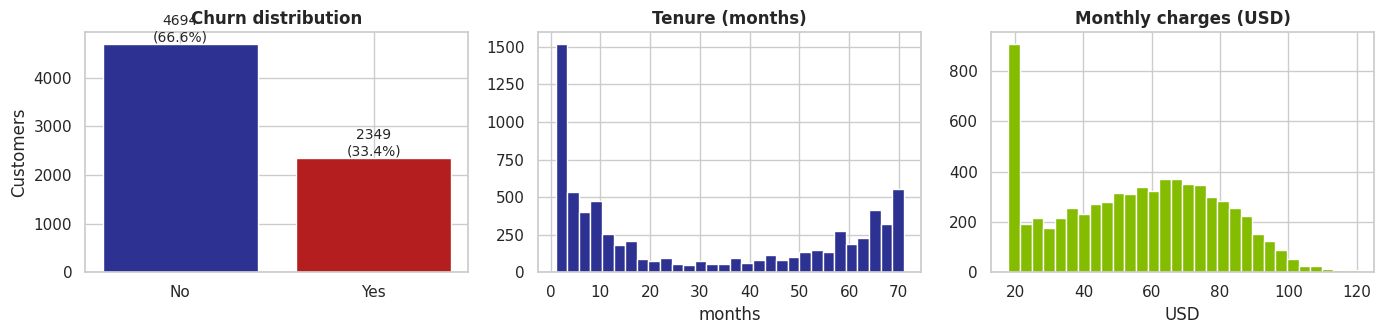

In [6]:
# Quick overview
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Churn rate
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=[IEBLUE, IERED])
axes[0].set_title('Churn distribution')
axes[0].set_ylabel('Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)

# Tenure
axes[1].hist(df['tenure'], bins=30, color=IEBLUE, edgecolor='white')
axes[1].set_title('Tenure (months)')
axes[1].set_xlabel('months')

# Monthly charges
axes[2].hist(df['MonthlyCharges'], bins=30, color=IEGREEN, edgecolor='white')
axes[2].set_title('Monthly charges (USD)')
axes[2].set_xlabel('USD')

plt.tight_layout()
plt.show()


---
#### **Part 1 — Foundations: every metric is an estimate ± uncertainty**
---
Before testing anything, let's **see** that a single number on a single split is noisy.
We'll resample the dataset many times and watch the churn rate jiggle.

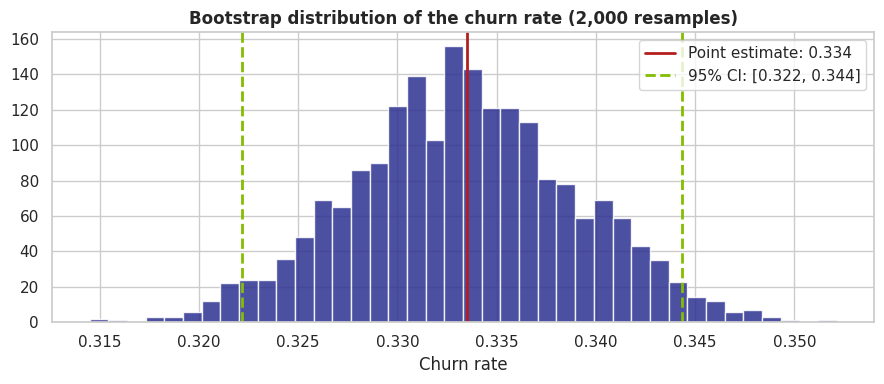

The "true" churn rate could plausibly be anywhere in [0.322, 0.344].
Reporting just the point estimate hides this entire band of uncertainty.


In [7]:
# Bootstrap the churn rate to visualize sampling uncertainty
n_boot = 2000
boot_rates = np.array([
    (df['Churn'].sample(len(df), replace=True, random_state=i) == 'Yes').mean()
    for i in range(n_boot)
])

point_estimate = (df['Churn'] == 'Yes').mean()
ci_low, ci_high = np.percentile(boot_rates, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_rates, bins=40, color=IEBLUE, edgecolor='white', alpha=0.85)
ax.axvline(point_estimate, color=IERED, lw=2, label=f'Point estimate: {point_estimate:.3f}')
ax.axvline(ci_low,  color=IEGREEN, lw=2, ls='--', label=f'95% CI: [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(ci_high, color=IEGREEN, lw=2, ls='--')
ax.set_title('Bootstrap distribution of the churn rate (2,000 resamples)')
ax.set_xlabel('Churn rate')
ax.legend()
plt.tight_layout(); plt.show()

print(f'The "true" churn rate could plausibly be anywhere in [{ci_low:.3f}, {ci_high:.3f}].')
print('Reporting just the point estimate hides this entire band of uncertainty.')


**Takeaway.** The churn rate has a 95 % CI roughly ±1 percentage point wide.
If someone reports a "0.5 % improvement," that's already inside the noise band — you need a test to see whether it's real.

---
#### **Part 2 — A/B testing: did the retention campaign work?**
---
**Scenario.** Marketing ran a retention email campaign on a random half of month-to-month
customers (the segment most at risk). They want to know: *did churn really go down?*

In [8]:
# Simulate an A/B test on the at-risk segment
m2m = df[df['Contract'] == 'Month-to-month'].copy()
print(f'At-risk segment size: {len(m2m):,} customers')

# Random 50/50 assignment
m2m['group'] = RNG.choice(['A_control', 'B_campaign'], size=len(m2m))

# Apply the intervention: campaign reduces churn probability by ~3 pp
def simulate_outcome(row):
    churn = row['Churn'] == 'Yes'
    if row['group'] == 'B_campaign' and churn:
        # Retain a fraction of would-be churners
        if RNG.random() < 0.07:        # true treatment effect
            return 'No'
    return row['Churn']

m2m['outcome'] = m2m.apply(simulate_outcome, axis=1)

summary = m2m.groupby('group')['outcome'].apply(lambda s: (s == 'Yes').mean())
print('\nObserved churn rates:')
print(summary.to_string())
print(f"\nAbsolute lift (B - A): {(summary['B_campaign'] - summary['A_control'])*100:+.2f} pp")


At-risk segment size: 3,857 customers

Observed churn rates:
group
A_control     0.461895
B_campaign    0.436031

Absolute lift (B - A): -2.59 pp


In [9]:
# Two-proportion z-test
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

a = m2m[m2m['group'] == 'A_control']
b = m2m[m2m['group'] == 'B_campaign']

count = np.array([(a['outcome']=='Yes').sum(), (b['outcome']=='Yes').sum()])
nobs  = np.array([len(a), len(b)])

z, pval = proportions_ztest(count, nobs)
ci = confint_proportions_2indep(count[1], nobs[1], count[0], nobs[0], method='wald')

p_a, p_b = count / nobs
print(f'p_A (control)   = {p_a:.4f}   ({count[0]} / {nobs[0]})')
print(f'p_B (campaign)  = {p_b:.4f}   ({count[1]} / {nobs[1]})')
print(f'Absolute diff   = {p_b - p_a:+.4f}')
print(f'Z statistic     = {z:.3f}')
print(f'p-value         = {pval:.4f}')
print(f'95% CI for diff = [{ci[0]:+.4f}, {ci[1]:+.4f}]')

verdict = "REJECT H0 — campaign had an effect" if pval < 0.05 else "FAIL TO REJECT H0 — not enough evidence"
print(f'\n→ Decision (α = 0.05): {verdict}')


p_A (control)   = 0.4619   (897 / 1942)
p_B (campaign)  = 0.4360   (835 / 1915)
Absolute diff   = -0.0259
Z statistic     = 1.615
p-value         = 0.1064
95% CI for diff = [-0.0572, +0.0055]

→ Decision (α = 0.05): FAIL TO REJECT H0 — not enough evidence


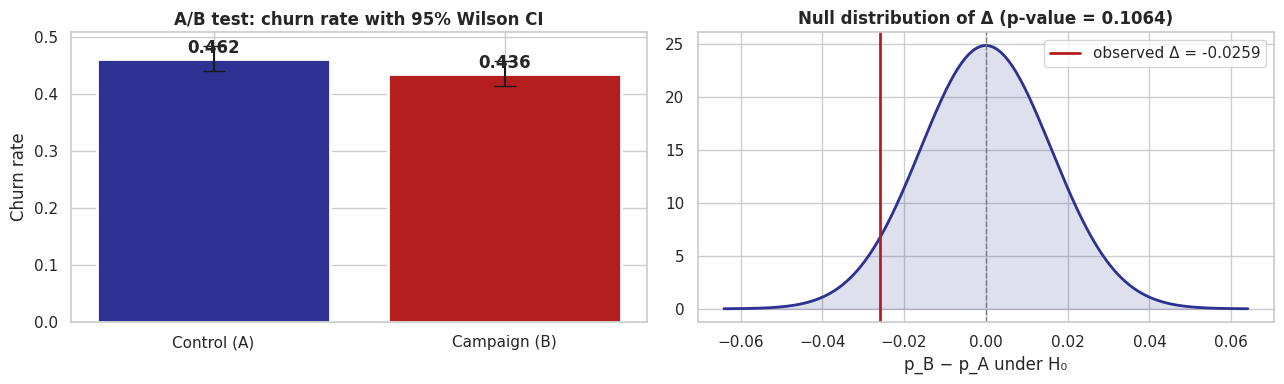

In [10]:
# Visualize the A/B comparison with CIs
from statsmodels.stats.proportion import proportion_confint

cis = [proportion_confint(c, n, method='wilson') for c, n in zip(count, nobs)]
means = count / nobs
err_lo = means - np.array([c[0] for c in cis])
err_hi = np.array([c[1] for c in cis]) - means

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bars with CIs
axes[0].bar(['Control (A)', 'Campaign (B)'], means,
            yerr=[err_lo, err_hi], color=[IEBLUE, IERED],
            capsize=8, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Churn rate')
axes[0].set_title('A/B test: churn rate with 95% Wilson CI')
for i, m in enumerate(means):
    axes[0].text(i, m + 0.01, f'{m:.3f}', ha='center', fontweight='bold')

# Right: difference distribution under H0 (null) vs observed
diff_obs = p_b - p_a
# null SE
p_pool = count.sum() / nobs.sum()
se_null = np.sqrt(p_pool*(1-p_pool)*(1/nobs[0] + 1/nobs[1]))
xs = np.linspace(-4*se_null, 4*se_null, 400)
axes[1].plot(xs, stats.norm.pdf(xs, 0, se_null), color=IEBLUE, lw=2)
axes[1].fill_between(xs, stats.norm.pdf(xs, 0, se_null), color=IEBLUE, alpha=0.15)
axes[1].axvline(diff_obs, color=IERED, lw=2, label=f'observed Δ = {diff_obs:+.4f}')
axes[1].axvline(0, color=IEGRAY, lw=1, ls='--')
axes[1].set_title(f'Null distribution of Δ (p-value = {pval:.4f})')
axes[1].set_xlabel('p_B − p_A under H₀')
axes[1].legend()

plt.tight_layout(); plt.show()


### Sample-size / power analysis
Before running the test, how large should each group be to detect a 3 pp lift with 80 % power?

 MDE (abs pp)  Cohen's h  n per group
         0.01   0.020296        38109
         0.02   0.040667         9492
         0.03   0.061124         4202
         0.05   0.102332         1500
         0.07   0.144002          758


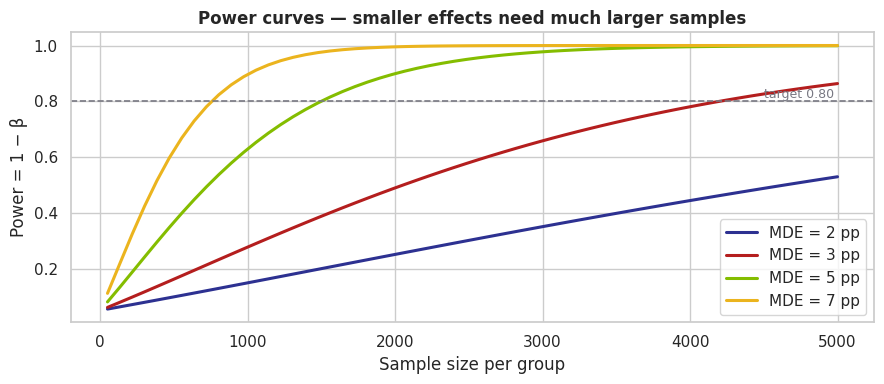

In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline = 0.42      # baseline churn in at-risk segment
mde_list = [0.01, 0.02, 0.03, 0.05, 0.07]
alpha, power = 0.05, 0.80
analysis = NormalIndPower()

rows = []
for mde in mde_list:
    es = proportion_effectsize(baseline, baseline - mde)
    n = analysis.solve_power(effect_size=es, alpha=alpha, power=power, alternative='two-sided')
    rows.append((mde, abs(es), int(np.ceil(n))))

power_df = pd.DataFrame(rows, columns=['MDE (abs pp)', "Cohen's h", 'n per group'])
print(power_df.to_string(index=False))

# Plot power curves
fig, ax = plt.subplots(figsize=(9, 4))
ns = np.linspace(50, 5000, 60)
for mde, color in zip([0.02, 0.03, 0.05, 0.07], PALETTE):
    es = proportion_effectsize(baseline, baseline - mde)
    powers = [analysis.solve_power(effect_size=abs(es), nobs1=n, alpha=alpha, alternative='two-sided') for n in ns]
    ax.plot(ns, powers, lw=2.2, color=color, label=f'MDE = {mde*100:.0f} pp')
ax.axhline(0.8, color=IEGRAY, ls='--', lw=1.2)
ax.text(4500, 0.81, 'target 0.80', color=IEGRAY, fontsize=9)
ax.set_xlabel('Sample size per group')
ax.set_ylabel('Power = 1 − β')
ax.set_title('Power curves — smaller effects need much larger samples')
ax.legend(); plt.tight_layout(); plt.show()


**Takeaway.** Detecting a tiny 1 pp lift would require ≈40k customers per arm — for many products that's infeasible. *Always compute the required n before running the test.*

---
#### **Part 3 — Classical tests for feature → target screening**
---

We screen each feature for its association with `Churn` using the right test for its type.

#### **Part 3.1 Chi-square test of independence: `Contract` vs `Churn`**

Contingency table:
Churn             No   Yes
Contract                  
Month-to-month  2058  1799
One year        1144   335
Two year        1492   215

Chi² = 713.55   df = 2   p-value = 1.13e-155
Cramér's V = 0.318   (moderate)


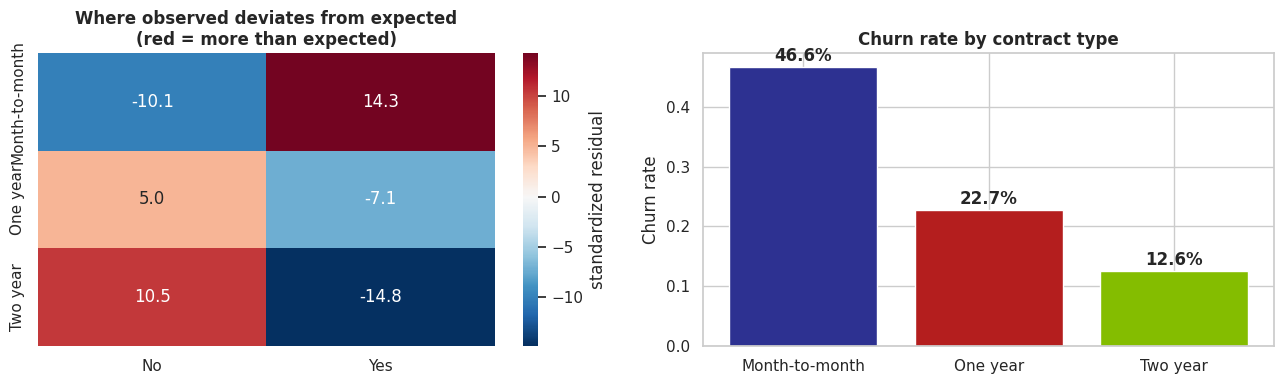

In [12]:
# Contingency table
ct = pd.crosstab(df['Contract'], df['Churn'])
print('Contingency table:')
print(ct)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"\nChi² = {chi2:.2f}   df = {dof}   p-value = {p_chi:.2e}")
print(f"Cramér's V = {cramers_v:.3f}   "
      f"({'strong' if cramers_v>0.4 else 'moderate' if cramers_v>0.2 else 'weak' if cramers_v>0.1 else 'negligible'})")

# Visualize: observed vs expected + churn rate by contract
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap of standardized residuals
resid = (ct.values - expected) / np.sqrt(expected)
sns.heatmap(resid, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            xticklabels=ct.columns, yticklabels=ct.index,
            ax=axes[0], cbar_kws={'label': 'standardized residual'})
axes[0].set_title('Where observed deviates from expected\n(red = more than expected)')

# Churn rate by contract
rates = df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
axes[1].bar(rates.index, rates.values, color=PALETTE[:3], edgecolor='white')
axes[1].set_ylabel('Churn rate')
axes[1].set_title('Churn rate by contract type')
for i, v in enumerate(rates.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout(); plt.show()


Month-to-month customers churn dramatically more than yearly ones — confirmed by both
the chi-square test (p ≪ 0.001) and Cramér's V.

> **Significance ≠ strength.** With 7,000 rows almost any feature will be "significant." Cramér's V tells you whether the association is **practically** large.

#### **Part 3.2 Two-sample t-test & Mann–Whitney: `tenure` between churners and non-churners**

Mean tenure (churn=Yes): 15.4 months   n = 2349
Mean tenure (churn=No) : 36.6 months   n = 4694

Welch's t-test   : t = -37.37,  p = 3.02e-275
Mann–Whitney U   : U = 3101958,  p = 7.35e-198
Cohen's d (effect): -0.86   (large)


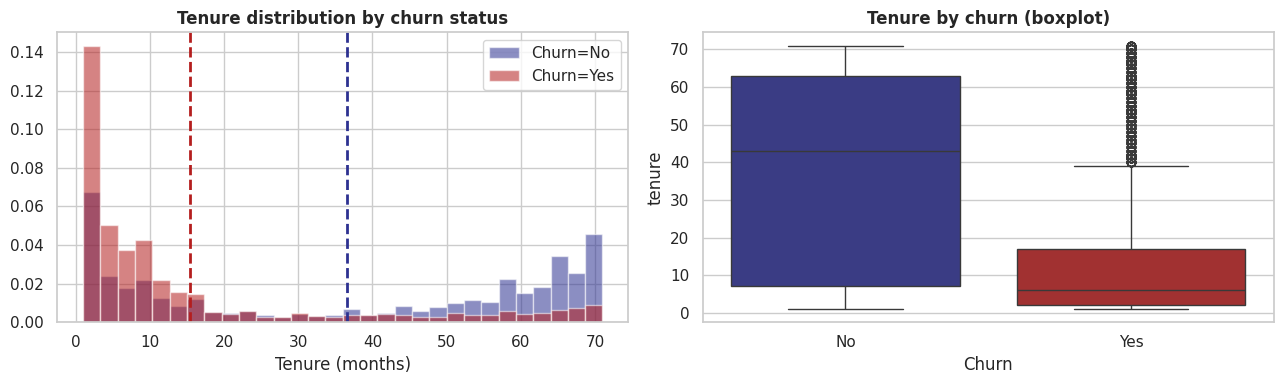

In [13]:
churn_yes = df.loc[df['Churn'] == 'Yes', 'tenure']
churn_no  = df.loc[df['Churn'] == 'No',  'tenure']

# Welch's t (does not assume equal variance)
t_stat, p_t = stats.ttest_ind(churn_yes, churn_no, equal_var=False)
# Mann-Whitney (no normality assumption)
u_stat, p_u = stats.mannwhitneyu(churn_yes, churn_no, alternative='two-sided')
# Cohen's d (effect size)
pooled_sd = np.sqrt(((len(churn_yes)-1)*churn_yes.var() + (len(churn_no)-1)*churn_no.var())
                    / (len(churn_yes) + len(churn_no) - 2))
cohen_d = (churn_yes.mean() - churn_no.mean()) / pooled_sd

print(f"Mean tenure (churn=Yes): {churn_yes.mean():.1f} months   n = {len(churn_yes)}")
print(f"Mean tenure (churn=No) : {churn_no.mean():.1f} months   n = {len(churn_no)}")
print(f"\nWelch's t-test   : t = {t_stat:.2f},  p = {p_t:.2e}")
print(f"Mann–Whitney U   : U = {u_stat:.0f},  p = {p_u:.2e}")
print(f"Cohen's d (effect): {cohen_d:.2f}   "
      f"({'large' if abs(cohen_d)>0.8 else 'medium' if abs(cohen_d)>0.5 else 'small'})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# KDE
for label, data, color in [('No', churn_no, IEBLUE), ('Yes', churn_yes, IERED)]:
    axes[0].hist(data, bins=30, alpha=0.55, color=color, label=f'Churn={label}', density=True, edgecolor='white')
    axes[0].axvline(data.mean(), color=color, lw=2, ls='--')
axes[0].set_title('Tenure distribution by churn status')
axes[0].set_xlabel('Tenure (months)'); axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1], palette=[IEBLUE, IERED])
axes[1].set_title('Tenure by churn (boxplot)')
plt.tight_layout(); plt.show()


**Takeaway.** Both tests agree the difference is real. We prefer **Mann–Whitney** here because tenure is clearly non-normal (heavy left skew), but both lead to the same decision — a strong reassurance the result isn't an artefact of the test choice.

#### **Part 3.3 One-way ANOVA: `MonthlyCharges` across `InternetService` levels**

ANOVA          : F = 7060.30,  p = 0.00e+00
Kruskal–Wallis : H = 4704.59,  p = 0.00e+00

Tukey HSD post-hoc:
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
        DSL Fiber optic  24.5757   0.0  23.6928  25.4585   True
        DSL          No -25.1309   0.0 -26.1818 -24.0801   True
Fiber optic          No -49.7066   0.0 -50.7052 -48.7081   True
---------------------------------------------------------------


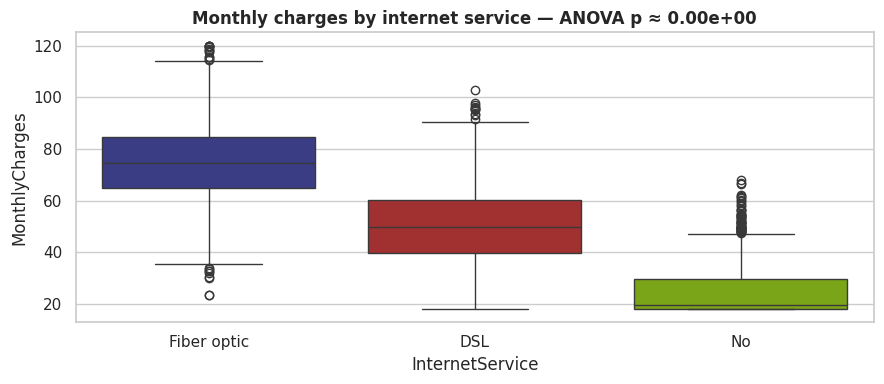

In [14]:
groups = [df.loc[df['InternetService']==svc, 'MonthlyCharges'].values
          for svc in ['DSL', 'Fiber optic', 'No']]

f_stat, p_anova = stats.f_oneway(*groups)
# Non-parametric counterpart
h_stat, p_kw = stats.kruskal(*groups)

print(f"ANOVA          : F = {f_stat:.2f},  p = {p_anova:.2e}")
print(f"Kruskal–Wallis : H = {h_stat:.2f},  p = {p_kw:.2e}")

# Post-hoc Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(df['MonthlyCharges'], df['InternetService'])
print('\nTukey HSD post-hoc:')
print(tukey)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', palette=PALETTE[:3], ax=ax)
ax.set_title('Monthly charges by internet service — ANOVA p ≈ {:.2e}'.format(p_anova))
plt.tight_layout(); plt.show()


#### **Part 3.4 Correlation: `tenure` vs `TotalCharges`**

Pearson  r = 0.838,  p = 0.00e+00
Spearman ρ = 0.914,  p = 0.00e+00


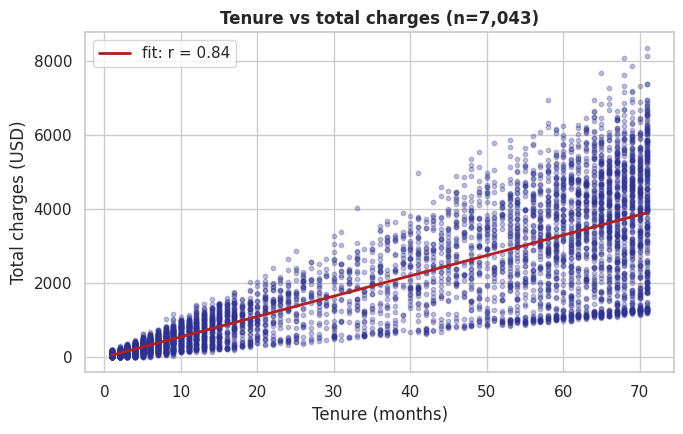

In [15]:
r, p_r = stats.pearsonr(df['tenure'], df['TotalCharges'])
rho, p_rho = stats.spearmanr(df['tenure'], df['TotalCharges'])

print(f"Pearson  r = {r:.3f},  p = {p_r:.2e}")
print(f"Spearman ρ = {rho:.3f},  p = {p_rho:.2e}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df['tenure'], df['TotalCharges'], alpha=0.3, s=10, color=IEBLUE)
# Trend line
z = np.polyfit(df['tenure'], df['TotalCharges'], 1)
xs = np.linspace(df['tenure'].min(), df['tenure'].max(), 100)
ax.plot(xs, z[0]*xs + z[1], color=IERED, lw=2, label=f'fit: r = {r:.2f}')
ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Total charges (USD)')
ax.set_title('Tenure vs total charges (n=7,043)')
ax.legend(); plt.tight_layout(); plt.show()


#### **Part 3.5 Cheat-sheet view: all features tested at once**

In [16]:
# Apply the right test per (feature, target) type pair
results = []

categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']
numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in categorical:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
    results.append({'feature': col, 'type': 'categorical', 'test': 'Chi²',
                    'statistic': chi2, 'p_value': p, 'effect_size': v, 'effect_metric': "Cramér's V"})

for col in numerical:
    a = df.loc[df['Churn']=='Yes', col]
    b = df.loc[df['Churn']=='No',  col]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    d = (a.mean() - b.mean()) / np.sqrt((a.var()*(len(a)-1) + b.var()*(len(b)-1)) / (len(a)+len(b)-2))
    results.append({'feature': col, 'type': 'numerical', 'test': "Welch's t",
                    'statistic': t, 'p_value': p, 'effect_size': abs(d), 'effect_metric': "Cohen's |d|"})

res_df = pd.DataFrame(results).sort_values('effect_size', ascending=False)
res_df['p_value'] = res_df['p_value'].apply(lambda x: f'{x:.2e}')
res_df


,feature,type,test,statistic,p_value,effect_size,effect_metric
8,tenure,numerical,Welch's t,-37.366794,3.02e-275,0.856273,Cohen's |d|
10,TotalCharges,numerical,Welch's t,-28.932497,9.74e-173,0.657693,Cohen's |d|
4,Contract,categorical,Chi²,713.551267,1.13e-155,0.318298,Cramér's V
9,MonthlyCharges,numerical,Welch's t,5.537016,3.24e-08,0.139197,Cohen's |d|
6,InternetService,categorical,Chi²,54.298831,1.62e-12,0.087804,Cramér's V
5,PaymentMethod,categorical,Chi²,27.021380,5.83e-06,0.061941,Cramér's V
1,SeniorCitizen,categorical,Chi²,10.979997,9.21e-04,0.039484,Cramér's V
7,PaperlessBilling,categorical,Chi²,8.697080,3.19e-03,0.035140,Cramér's V
2,Partner,categorical,Chi²,0.666696,4.14e-01,0.009729,Cramér's V
0,gender,categorical,Chi²,0.059485,8.07e-01,0.002906,Cramér's V


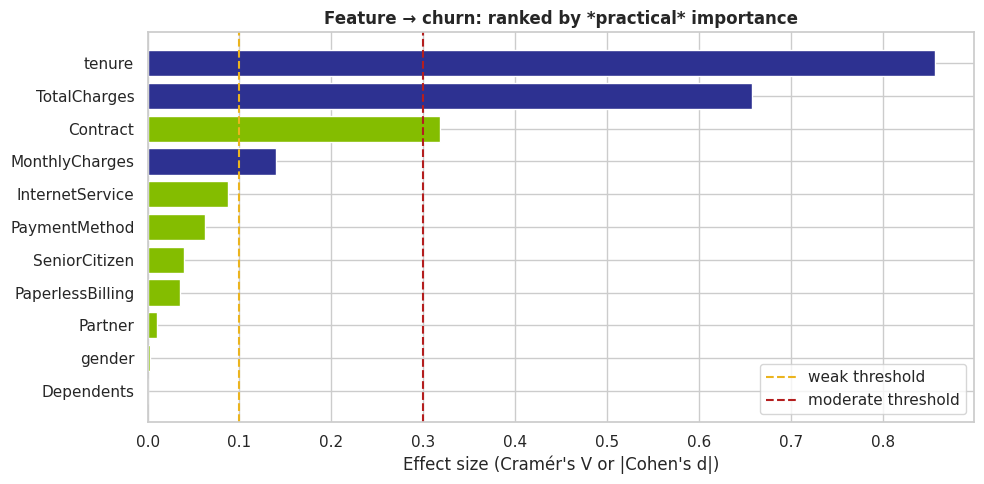

In [14]:
# Sort by effect size — the *practical* ranking
fig, ax = plt.subplots(figsize=(10, 5))
res_plot = pd.DataFrame(results).sort_values('effect_size')
colors = [IEGREEN if t=='categorical' else IEBLUE for t in res_plot['type']]
ax.barh(res_plot['feature'], res_plot['effect_size'], color=colors, edgecolor='white')
ax.axvline(0.1, color=IEYELLOW, ls='--', label='weak threshold')
ax.axvline(0.3, color=IERED, ls='--', label='moderate threshold')
ax.set_xlabel('Effect size (Cramér\'s V or |Cohen\'s d|)')
ax.set_title('Feature → churn: ranked by *practical* importance')
ax.legend(); plt.tight_layout(); plt.show()


**Takeaway.** `Contract` and `tenure` dominate. `gender` may still test "significant" with this much data — but its effect size is essentially zero, so it's noise dressed in a p-value.

---
#### **Part 4 — Model comparison: is Random Forest *really* better than Logistic Regression?**
---

We train both models on the same churn dataset and compare them properly with:
1. A **McNemar test** on the held-out test set (fixed-split comparison)
2. A **paired t-test on 10 CV folds** (cross-validated comparison)

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Prep data
X = df.drop(columns=['Churn'])
y = (df['Churn'] == 'Yes').astype(int)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = [c for c in X.columns if c not in num_cols]

pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

logreg = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=2000, random_state=42))])
rf     = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
logreg.fit(X_tr, y_tr);  rf.fit(X_tr, y_tr)

pred_lr = logreg.predict(X_te)
pred_rf = rf.predict(X_te)

acc_lr = (pred_lr == y_te).mean()
acc_rf = (pred_rf == y_te).mean()
print(f'Test accuracy — LogReg: {acc_lr:.4f}')
print(f'Test accuracy — RForest: {acc_rf:.4f}')
print(f'Raw difference        : {acc_rf - acc_lr:+.4f}')
print('… but is this a real improvement?')


Test accuracy — LogReg: 0.7706
Test accuracy — RForest: 0.7382
Raw difference        : -0.0324
… but is this a real improvement?


#### **Part 4.1 McNemar test — pairs on the same test examples**

McNemar contingency (rows = LR, cols = RF):
            RF correct  RF wrong
LR correct        1235       122
LR wrong            65       339

McNemar χ² = 16.77,  p = 0.0000
Only the off-diagonal cells (disagreements) carry information about which model is better.


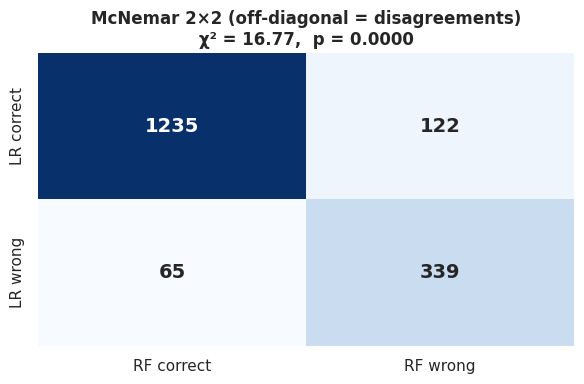

In [18]:
from statsmodels.stats.contingency_tables import mcnemar

# Build the 2x2 contingency on per-example correctness
lr_correct = (pred_lr == y_te.values)
rf_correct = (pred_rf == y_te.values)

n11 = ((lr_correct) & (rf_correct)).sum()
n10 = ((lr_correct) & (~rf_correct)).sum()
n01 = ((~lr_correct) & (rf_correct)).sum()
n00 = ((~lr_correct) & (~rf_correct)).sum()
table = np.array([[n11, n10], [n01, n00]])

mc = mcnemar(table, exact=False, correction=True)
print('McNemar contingency (rows = LR, cols = RF):')
print(pd.DataFrame(table,
                   index=['LR correct', 'LR wrong'],
                   columns=['RF correct', 'RF wrong']))
print(f'\nMcNemar χ² = {mc.statistic:.2f},  p = {mc.pvalue:.4f}')
print('Only the off-diagonal cells (disagreements) carry information about which model is better.')

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(table, annot=True, fmt='d',
            xticklabels=['RF correct', 'RF wrong'],
            yticklabels=['LR correct', 'LR wrong'],
            cmap='Blues', cbar=False, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'McNemar 2×2 (off-diagonal = disagreements)\nχ² = {mc.statistic:.2f},  p = {mc.pvalue:.4f}')
plt.tight_layout(); plt.show()


#### **Part 4.2 Paired t-test on 10 CV folds**

10-fold CV accuracy — LR:  0.7652 ± 0.0134
10-fold CV accuracy — RF:  0.7402 ± 0.0120
Mean per-fold diff (RF-LR): -0.0250
Paired t-test : t = -7.66,  p = 0.0000
(Note: CV folds share training data, so this test is mildly optimistic.)


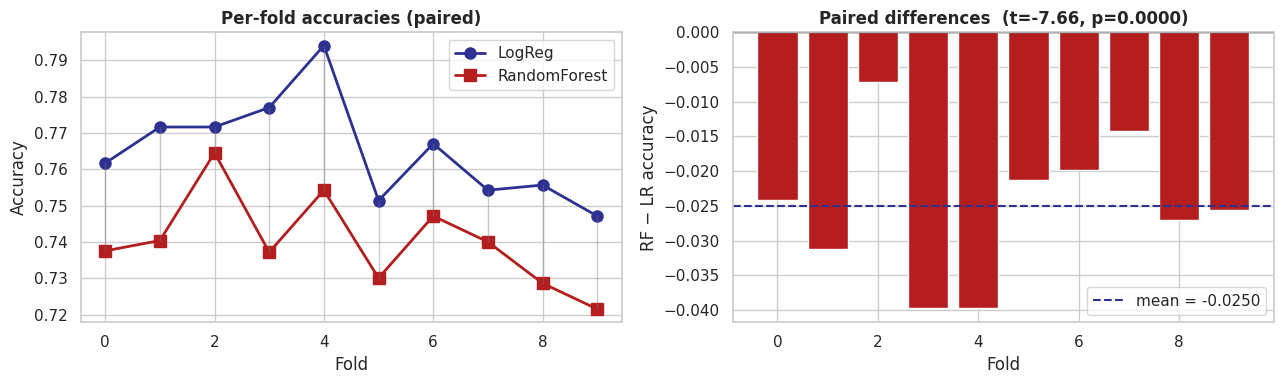

In [19]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_lr = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
scores_rf = cross_val_score(rf,     X, y, cv=cv, scoring='accuracy', n_jobs=-1)
diffs = scores_rf - scores_lr

t_paired, p_paired = stats.ttest_rel(scores_rf, scores_lr)
print(f'10-fold CV accuracy — LR:  {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')
print(f'10-fold CV accuracy — RF:  {scores_rf.mean():.4f} ± {scores_rf.std():.4f}')
print(f'Mean per-fold diff (RF-LR): {diffs.mean():+.4f}')
print(f'Paired t-test : t = {t_paired:.2f},  p = {p_paired:.4f}')
print('(Note: CV folds share training data, so this test is mildly optimistic.)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(10)
axes[0].plot(x, scores_lr, 'o-', color=IEBLUE, label='LogReg', lw=2, markersize=8)
axes[0].plot(x, scores_rf, 's-', color=IERED,  label='RandomForest', lw=2, markersize=8)
for i in range(10):
    axes[0].plot([i, i], [scores_lr[i], scores_rf[i]], color=IEGRAY, lw=1, alpha=0.4)
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Per-fold accuracies (paired)')
axes[0].legend()

axes[1].bar(x, diffs, color=[IEGREEN if d>0 else IERED for d in diffs], edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
axes[1].axhline(diffs.mean(), color=IEBLUE, ls='--', label=f'mean = {diffs.mean():+.4f}')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('RF − LR accuracy')
axes[1].set_title(f'Paired differences  (t={t_paired:.2f}, p={p_paired:.4f})')
axes[1].legend()
plt.tight_layout(); plt.show()


**Takeaway.** Both tests typically agree on a direction. The McNemar test is the right tool for a **fixed test set**; the paired CV t-test estimates uncertainty across folds. Reporting **only** the difference of point estimates (e.g. "0.4 % better") without a paired test is the most common mistake in model bake-offs.

---
#### **Part 5 — Multiple testing and distribution drift**
---

#### **Parrt5.1 Multiple testing: Bonferroni vs Benjamini–Hochberg**

We screen **20 candidate features** (some real, most pure noise) for association with churn.
With α = 0.05 and 20 tests, we expect ≈ 1 false positive by chance.

In [20]:
# Generate 17 random noise features + reuse 3 real ones
rng = np.random.default_rng(123)
feature_pvals = {}
for i in range(17):
    noise = rng.normal(size=len(df))
    _, p = stats.ttest_ind(noise[df['Churn']=='Yes'], noise[df['Churn']=='No'])
    feature_pvals[f'noise_{i+1}'] = p
# Real ones
for col in ['tenure', 'MonthlyCharges', 'SeniorCitizen']:
    a = df.loc[df['Churn']=='Yes', col]; b = df.loc[df['Churn']=='No', col]
    _, p = stats.ttest_ind(a, b, equal_var=False)
    feature_pvals[col] = p

p_series = pd.Series(feature_pvals).sort_values()
print('Raw p-values (sorted):')
print(p_series.apply(lambda x: f'{x:.4f}').to_string())

# Corrections
from statsmodels.stats.multitest import multipletests
_, p_bonf, _, _ = multipletests(p_series.values, alpha=0.05, method='bonferroni')
_, p_bh,   _, _ = multipletests(p_series.values, alpha=0.05, method='fdr_bh')

corr_df = pd.DataFrame({
    'feature': p_series.index,
    'raw_p': p_series.values,
    'Bonferroni': p_bonf,
    'BH (FDR)': p_bh,
    'sig_raw': p_series.values < 0.05,
    'sig_Bonf': p_bonf < 0.05,
    'sig_BH': p_bh < 0.05,
})
corr_df


Raw p-values (sorted):
tenure            0.0000
MonthlyCharges    0.0000
SeniorCitizen     0.0011
noise_13          0.0027
noise_11          0.0573
noise_10          0.0844
noise_4           0.4569
noise_15          0.5476
noise_5           0.5500
noise_1           0.5507
noise_9           0.5646
noise_12          0.6603
noise_17          0.8209
noise_8           0.8290
noise_7           0.8640
noise_16          0.8903
noise_3           0.9066
noise_2           0.9564
noise_14          0.9837
noise_6           0.9888


,feature,raw_p,Bonferroni,BH (FDR),sig_raw,sig_Bonf,sig_BH
0,tenure,3.020722e-275,6.041445e-274,6.041445e-274,True,True,True
1,MonthlyCharges,3.241787e-08,6.483575e-07,3.241787e-07,True,True,True
2,SeniorCitizen,1.104235e-03,2.208469e-02,7.361564e-03,True,True,True
3,noise_13,2.657287e-03,5.314573e-02,1.328643e-02,True,False,True
4,noise_11,5.728194e-02,1.000000e+00,2.291277e-01,False,False,False
5,noise_10,8.436388e-02,1.000000e+00,2.812129e-01,False,False,False
6,noise_4,4.569033e-01,1.000000e+00,9.888472e-01,False,False,False
7,noise_15,5.475508e-01,1.000000e+00,9.888472e-01,False,False,False
8,noise_5,5.500164e-01,1.000000e+00,9.888472e-01,False,False,False
9,noise_1,5.507207e-01,1.000000e+00,9.888472e-01,False,False,False


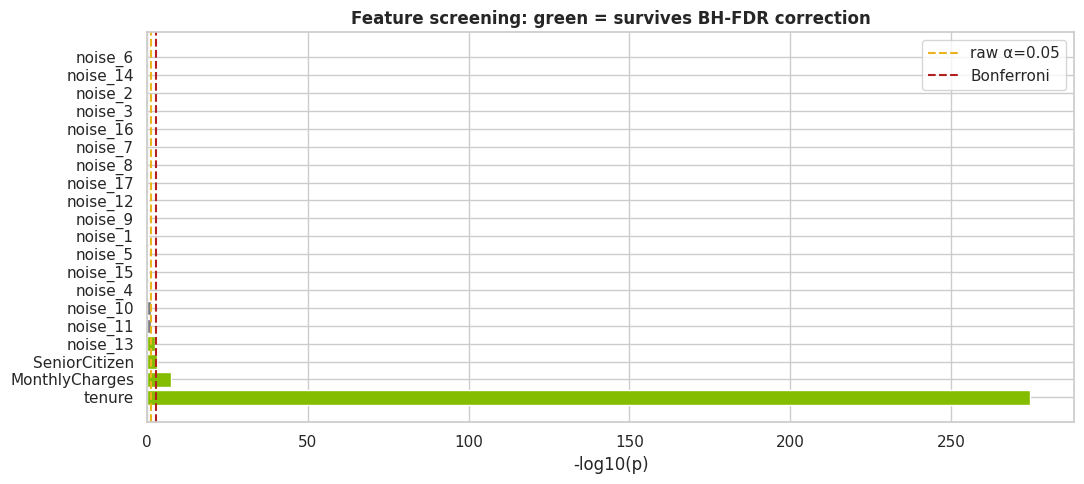


Features significant under each rule:
  Raw α=0.05  : 4
  Bonferroni  : 3
  BH (FDR)    : 4


In [21]:
# Visualize -log10(p) and which features survive each correction
fig, ax = plt.subplots(figsize=(11, 5))
y_pos = np.arange(len(corr_df))
ax.barh(y_pos, -np.log10(corr_df['raw_p']),
        color=[IEGREEN if s else IEGRAY for s in corr_df['sig_BH']], edgecolor='white')
ax.set_yticks(y_pos); ax.set_yticklabels(corr_df['feature'])
ax.axvline(-np.log10(0.05),               color=IEYELLOW, ls='--', label='raw α=0.05')
ax.axvline(-np.log10(0.05/len(corr_df)),  color=IERED,    ls='--', label='Bonferroni')
ax.set_xlabel('-log10(p)')
ax.set_title('Feature screening: green = survives BH-FDR correction')
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nFeatures significant under each rule:")
print(f"  Raw α=0.05  : {corr_df['sig_raw'].sum()}")
print(f"  Bonferroni  : {corr_df['sig_Bonf'].sum()}")
print(f"  BH (FDR)    : {corr_df['sig_BH'].sum()}")


**Takeaway.** Without correction, you'd "discover" noise features. Bonferroni is the strictest (controls family-wise error). BH-FDR is the standard in modern ML / genomics and lets through real signal while keeping the false-discovery rate bounded.

#### **Part 5.2 Distribution drift: KS test on production-like data**

Imagine the production traffic shifted toward higher monthly charges. Can we **detect** the drift?

KS statistic = 0.128,  p-value = 1.66e-50
PSI          = 0.116   (minor drift)


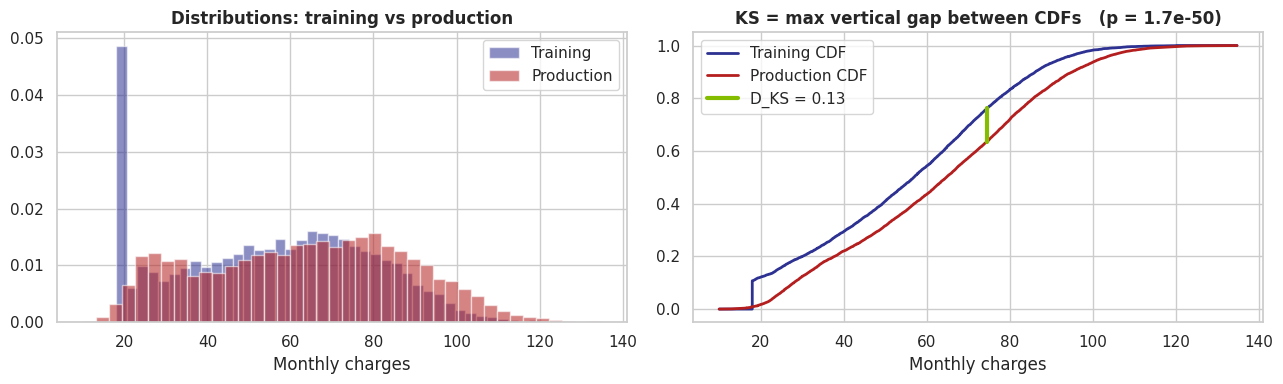

In [22]:
# "Training" distribution = our df, "production" = shifted version
train_mc = df['MonthlyCharges'].values
prod_mc  = train_mc + RNG.normal(8, 5, size=len(train_mc))   # +$8 mean shift

ks_stat, p_ks = stats.ks_2samp(train_mc, prod_mc)

# PSI (population stability index) — standard in credit risk
def psi(expected, actual, bins=10):
    breaks = np.quantile(expected, np.linspace(0, 1, bins+1))
    breaks[0]  -= 1e-6; breaks[-1] += 1e-6
    e_pct, _ = np.histogram(expected, bins=breaks)
    a_pct, _ = np.histogram(actual,   bins=breaks)
    e_pct = e_pct / e_pct.sum(); a_pct = a_pct / a_pct.sum()
    # avoid log(0)
    e_pct = np.where(e_pct==0, 1e-6, e_pct); a_pct = np.where(a_pct==0, 1e-6, a_pct)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

psi_val = psi(train_mc, prod_mc)
print(f'KS statistic = {ks_stat:.3f},  p-value = {p_ks:.2e}')
print(f'PSI          = {psi_val:.3f}   '
      f'({"OK" if psi_val<0.1 else "minor drift" if psi_val<0.25 else "major drift"})')

# Empirical CDFs
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_mc, bins=40, alpha=0.55, color=IEBLUE, label='Training', density=True)
axes[0].hist(prod_mc,  bins=40, alpha=0.55, color=IERED,  label='Production', density=True)
axes[0].set_title('Distributions: training vs production')
axes[0].set_xlabel('Monthly charges'); axes[0].legend()

xs = np.sort(np.concatenate([train_mc, prod_mc]))
cdf_tr = np.searchsorted(np.sort(train_mc), xs) / len(train_mc)
cdf_pr = np.searchsorted(np.sort(prod_mc),  xs) / len(prod_mc)
gap = np.abs(cdf_tr - cdf_pr); idx = gap.argmax()
axes[1].plot(xs, cdf_tr, color=IEBLUE, lw=2, label='Training CDF')
axes[1].plot(xs, cdf_pr, color=IERED,  lw=2, label='Production CDF')
axes[1].plot([xs[idx], xs[idx]], [cdf_tr[idx], cdf_pr[idx]], color=IEGREEN, lw=3,
             label=f'D_KS = {ks_stat:.2f}')
axes[1].set_title(f'KS = max vertical gap between CDFs   (p = {p_ks:.1e})')
axes[1].set_xlabel('Monthly charges'); axes[1].legend()
plt.tight_layout(); plt.show()


---
## Part 5b — Calibration: are predicted probabilities trustworthy?
---

Among customers we predict to churn with probability 0.7, roughly **70 %** should actually churn.

Brier score — LR: 0.1600   (lower = better)
Brier score — RF: 0.1739


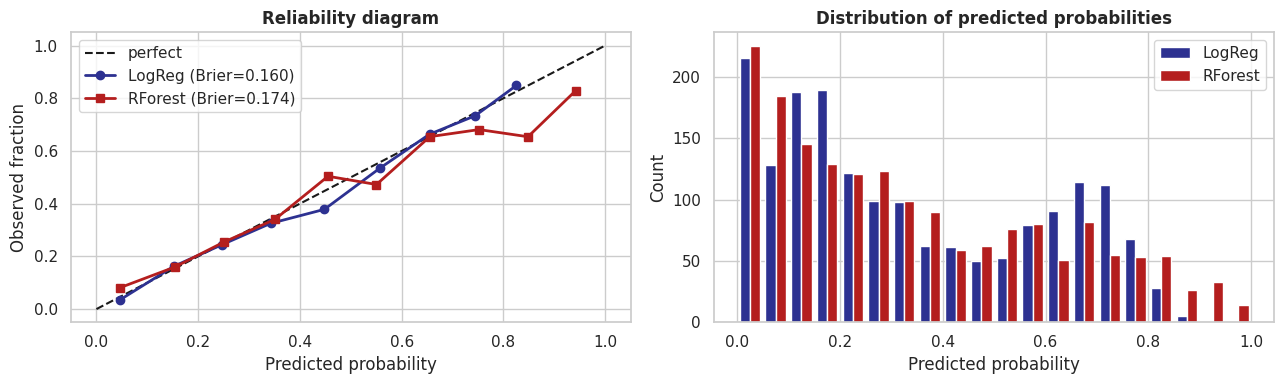

In [23]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

proba_lr = logreg.predict_proba(X_te)[:, 1]
proba_rf = rf.predict_proba(X_te)[:, 1]

frac_lr, mean_lr = calibration_curve(y_te, proba_lr, n_bins=10)
frac_rf, mean_rf = calibration_curve(y_te, proba_rf, n_bins=10)

brier_lr = brier_score_loss(y_te, proba_lr)
brier_rf = brier_score_loss(y_te, proba_rf)

print(f'Brier score — LR: {brier_lr:.4f}   (lower = better)')
print(f'Brier score — RF: {brier_rf:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([0, 1], [0, 1], 'k--', label='perfect')
axes[0].plot(mean_lr, frac_lr, 'o-', color=IEBLUE, lw=2, label=f'LogReg (Brier={brier_lr:.3f})')
axes[0].plot(mean_rf, frac_rf, 's-', color=IERED,  lw=2, label=f'RForest (Brier={brier_rf:.3f})')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Observed fraction')
axes[0].set_title('Reliability diagram'); axes[0].legend()

axes[1].hist([proba_lr, proba_rf], bins=20, color=[IEBLUE, IERED],
             label=['LogReg', 'RForest'], edgecolor='white')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of predicted probabilities'); axes[1].legend()
plt.tight_layout(); plt.show()


**Takeaway.** A model can be **accurate but mis-calibrated** (or vice versa). For threshold-based decisions — credit, fraud, medical risk — calibration may matter more than raw accuracy.

---
## 8. Workflow summary — the cheat sheet you'll use weekly

| Step | Question | Tool |
|---|---|---|
| 1 | What is the decision the test will inform? | (none — think) |
| 2 | What are the variable types? | (none — inspect) |
| 3 | Pick the right test | table below |
| 4 | Check assumptions (independence, normality, equal var) | plots + Shapiro / Levene |
| 5 | Run the test, **report 4 numbers**: statistic, p-value, CI, effect size | scipy / statsmodels |
| 6 | Translate to a business call | plain English |

### Test selection cheat-sheet

| Feature type | Target type | Parametric | Non-parametric |
|---|---|---|---|
| numerical | binary | Welch's t | Mann–Whitney U |
| numerical | multi-class | one-way ANOVA | Kruskal–Wallis |
| numerical | numerical | Pearson r | Spearman ρ |
| categorical | categorical | Chi-square independence | Fisher's exact (small n) |
| paired observations | — | paired t | Wilcoxon signed-rank |
| two classifiers, same test set | — | **McNemar** | — |
| two models, k folds | — | paired t on folds (corrected resampled t) | — |
| many tests | — | Bonferroni / BH-FDR | — |
| distribution drift | numerical | — | KS-test, PSI |
| distribution drift | categorical | Chi-square | — |

### Anti-patterns to avoid
1. **Peeking** at an A/B test before reaching the planned sample size
2. **p-hacking** by picking the test or metric after seeing the data
3. **Reporting only p-values** without effect size or CIs
4. **Fitting feature-selection tests outside CV** — leakage
5. **Conflating significance with importance** — large N makes everything "significant"